# ML - Thyroid Cancer Recurrance Prediction
In this project I aim to reproduce the machine learning workflow used in a published study on predicting thyroid cancer recurrence in patients diagnosed with thyroid cancer.  

**Reference Article**: https://link.springer.com/article/10.1007/s00405-023-08299-w#Sec7

# Library Imports

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')

# Install and import dataset

In [39]:
# Install UCI ML repository
!pip install ucimlrepo

In [40]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
differentiated_thyroid_cancer_recurrence = fetch_ucirepo(id=915)

# data (as pandas dataframes)
X = differentiated_thyroid_cancer_recurrence.data.features
y = differentiated_thyroid_cancer_recurrence.data.targets

# metadata
print(differentiated_thyroid_cancer_recurrence.metadata)

# variable information
print(differentiated_thyroid_cancer_recurrence.variables)

# Unite dataset for EDA
df = pd.concat([X, y], axis=1)


{'uci_id': 915, 'name': 'Differentiated Thyroid Cancer Recurrence', 'repository_url': 'https://archive.ics.uci.edu/dataset/915/differentiated+thyroid+cancer+recurrence', 'data_url': 'https://archive.ics.uci.edu/static/public/915/data.csv', 'abstract': 'This data set contains 13 clinicopathologic features aiming to predict recurrence of well differentiated thyroid cancer. The data set was collected in duration of 15 years and each patient was followed for at least 10 years.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 383, 'num_features': 16, 'feature_types': ['Real', 'Categorical', 'Integer'], 'demographics': ['Age', 'Gender'], 'target_col': ['Recurred'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2023, 'last_updated': 'Wed Mar 20 2024', 'dataset_doi': '10.24432/C5632J', 'creators': ['Shiva Borzooei', 'Aidin Tarokhian'], 'intro_paper': {'ID': 333, 'type': 'NA

# EDA

In [41]:
df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [42]:
print(df.shape)
df.nunique()

(383, 17)


,0
Age,65
Gender,2
Smoking,2
Hx Smoking,2
Hx Radiothreapy,2
Thyroid Function,5
Physical Examination,5
Adenopathy,6
Pathology,4
Focality,2


In [43]:
# Check missing values
df.isnull().sum()

,0
Age,0
Gender,0
Smoking,0
Hx Smoking,0
Hx Radiothreapy,0
Thyroid Function,0
Physical Examination,0
Adenopathy,0
Pathology,0
Focality,0


Dataset has 383 lines and 17 columns. There is no missing values. All categorical variables have low cardinality.

In [44]:
# Age distribution
df["Age"].describe()

,Age
count,383.000000
mean,40.866841
std,15.134494
min,15.000000
25%,29.000000
50%,37.000000
75%,51.000000
max,82.000000


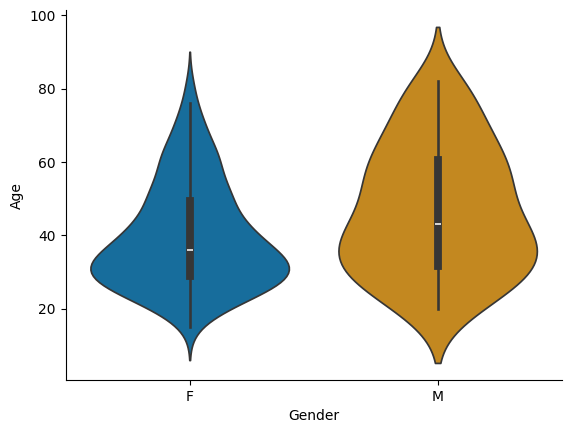

In [45]:
# Age distribution by Gender
df.groupby("Gender")["Age"].describe()
sns.violinplot(data=df, x="Gender", y="Age", palette="colorblind")
sns.despine()
plt.show()

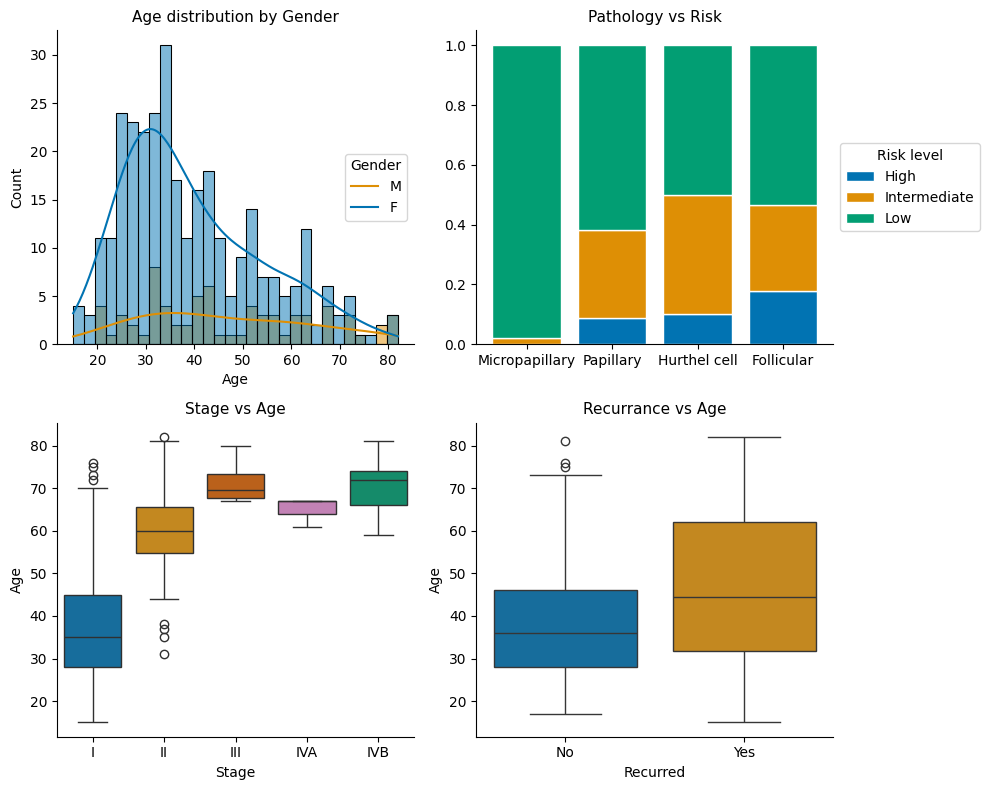

In [46]:
# Figures
fig, axes = plt.subplots(2, 2, figsize=(10, 8))


# Age
sns.histplot(data=df, x="Age", kde=True, hue="Gender", bins=30, ax=axes[0, 0], palette="colorblind")

axes[0, 0].set_title('Age distribution by Gender', fontsize=11)

axes[0, 0].legend(
    title="Gender",
    labels = ("M", "F"),
    loc="center right"
)

# Pathology vs Risk proportions
prop = (
    df.groupby("Pathology")["Risk"]
      .value_counts(normalize=True)
      .rename("risk_prop")
      .reset_index()
)

pivot = prop.pivot(index="Pathology", columns="Risk", values="risk_prop").fillna(0)
pivot = pivot.reindex(["Micropapillary", "Papillary", "Hurthel cell", "Follicular"])

groups = pivot.index # Pthology
categories = pivot.columns # Risk levels

palette = sns.color_palette("colorblind")
bottom = [0] * len(groups)

for cat, color in zip(categories, palette):
    values = pivot[cat].values
    axes[0, 1].bar(groups, values, bottom=bottom, color=color, edgecolor="white", label=cat)
    bottom = [b + v for b, v in zip(bottom, values)]

axes[0, 1].set_title('Pathology vs Risk', fontsize=11)

axes[0, 1].legend(
    title="Risk level",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

# Stage vs Age
order=["I", "II", "III", "IVA", "IVB"]
sns.boxplot(data=df, x="Stage", y="Age", hue="Stage", ax=axes[1, 0], palette="colorblind", order=order)

axes[1, 0].set_title('Stage vs Age', fontsize=11)

# Recurrance vs Age
sns.boxplot(data=df, x="Recurred", y="Age", hue="Recurred", ax=axes[1, 1], palette="colorblind")

axes[1, 1].set_title('Recurrance vs Age', fontsize=11)

# Plot
sns.despine()
plt.tight_layout()
plt.show()



There are more female than male patients, with similar age distributions across genders. Higher ATA risk is more common within Follicular and Hürthle cell cancer types. Cancer stage shows a positive association with age, with more advanced stages appearing in older patients. Thyroid cancer recurrence is also more frequent among older patients.

# Preprocessing, hyperparameters and pipelines

In [47]:
# Partition X and y (predictors and target) given by import
# Column types:
categorical_cols = X.select_dtypes(include=["object", "category"]).columns
numeric_cols = X.select_dtypes(include=np.number).columns
print("Categorical: ",categorical_cols)
print("Numeric: ", numeric_cols)

# Encoding categorical and standardizing numerical cols:
prep = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("numeric", StandardScaler(), numeric_cols)
    ],
    remainder='passthrough'
)

# Create pipelines (avoid data leakage) with preprocess and model
pipe_knn = Pipeline([
    ("preprocess", prep),
    ("knn", KNeighborsClassifier())
])

pipe_rf = Pipeline([
    ("preprocess", prep),
    ("rf", RandomForestClassifier())
])

pipe_svm = Pipeline([
    ("preprocess", prep),
    ("svm", SVC())
])

# Hyperparameters for each model
param_knn = {
    "knn__n_neighbors": [3, 5, 7, 9, 11],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

param_rf = {
    "rf__n_estimators": [100, 200, 300],
    "rf__max_depth": [None, 5, 10],
    "rf__min_samples_split": [2, 5, 10]
}

param_svm = {
    "svm__C": [0.1, 1, 10],
    "svm__kernel": ["linear", "rbf"],
    "svm__gamma": ["scale", "auto"]
}

Categorical:  Index(['Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy',
       'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology',
       'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response'],
      dtype='object')
Numeric:  Index(['Age'], dtype='object')


# Grid search and cross-validation

In [48]:
# Grids
grid_knn = GridSearchCV(pipe_knn, param_knn, cv=5)
grid_rf  = GridSearchCV(pipe_rf,  param_rf,  cv=5)
grid_svm = GridSearchCV(pipe_svm, param_svm, cv=5)

# Training
print("Training KNN...")
grid_knn.fit(X, y)
print("Training RF...")
grid_rf.fit(X, y)
print("Training SVM...")
grid_svm.fit(X, y)

# Results fro best models
print("KNN:", grid_knn.best_score_, grid_knn.best_params_)
print("RF:",  grid_rf.best_score_,  grid_rf.best_params_)
print("SVM:", grid_svm.best_score_, grid_svm.best_params_)


Training KNN...
Training RF...
Training SVM...
KNN: 0.8719412166780586 {'knn__metric': 'manhattan', 'knn__n_neighbors': 11, 'knn__weights': 'distance'}
RF: 0.9109364319890636 {'rf__max_depth': None, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}
SVM: 0.9084073820915926 {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}


# Final evaluation

In [49]:
# Split into training and test:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

models = {
    "KNN": grid_knn.best_estimator_,
    "RF": grid_rf.best_estimator_,
    "SVM": grid_svm.best_estimator_
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(name, model.score(X_test, y_test))




KNN 0.9166666666666666
RF 0.9791666666666666
SVM 0.96875


# Predictions

In [50]:
y_pred_knn = best_model_knn.predict(X_test)
y_pred_rf  = best_model_rf.predict(X_test)
y_pred_svm = best_model_svm.predict(X_test)

# Model comparison

In [51]:
# Confusion matrix
print("Knn\n", confusion_matrix(y_test, y_pred_knn))
print("RF\n", confusion_matrix(y_test, y_pred_rf))
print("SVM\n", confusion_matrix(y_test, y_pred_svm))

Knn
 [[67  1]
 [ 7 21]]
RF
 [[68  0]
 [ 2 26]]
SVM
 [[68  0]
 [ 3 25]]


In [52]:
# Classification report
print("KNN")
print(classification_report(y_test, y_pred_knn))

print("RandomForest")
print(classification_report(y_test, y_pred_rf))

print("SVM")
print(classification_report(y_test, y_pred_svm))

KNN
              precision    recall  f1-score   support

          No       0.91      0.99      0.94        68
         Yes       0.95      0.75      0.84        28

    accuracy                           0.92        96
   macro avg       0.93      0.87      0.89        96
weighted avg       0.92      0.92      0.91        96

RandomForest
              precision    recall  f1-score   support

          No       0.97      1.00      0.99        68
         Yes       1.00      0.93      0.96        28

    accuracy                           0.98        96
   macro avg       0.99      0.96      0.97        96
weighted avg       0.98      0.98      0.98        96

SVM
              precision    recall  f1-score   support

          No       0.96      1.00      0.98        68
         Yes       1.00      0.89      0.94        28

    accuracy                           0.97        96
   macro avg       0.98      0.95      0.96        96
weighted avg       0.97      0.97      0.97        96

In [53]:
# AUC
print("KNN AUC:", roc_auc_score(y_test, models['KNN'].predict_proba(X_test)[:,1]))
print("RF AUC:",  roc_auc_score(y_test, models['RF'].predict_proba(X_test)[:,1]))
print("SVM AUC:", roc_auc_score(y_test, models['SVM'].decision_function(X_test)))

KNN AUC: 0.9708508403361346
RF AUC: 0.9976365546218487
SVM AUC: 0.9963235294117647


In [54]:
# Summary table
sum = pd.DataFrame({
    "Model": ["KNN", "RandomForest", "SVM"],
    "Accuracy": [
        models['KNN'].score(X_test, y_test),
        models['RF'].score(X_test, y_test),
        models['SVM'].score(X_test, y_test)
    ],
    "AUC": [
        roc_auc_score(y_test, models['KNN'].predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, models['RF'].predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, models['SVM'].decision_function(X_test))
    ]
})

sum.sort_values("AUC", ascending=False)


,Model,Accuracy,AUC
1,RandomForest,0.979167,0.997637
2,SVM,0.968750,0.996324
0,KNN,0.916667,0.970851
